### Imports and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

df = pd.read_csv("../data/aqi_features.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nColumns:\n{df.dtypes}")
print(f"\nNull values:\n{df.isnull().sum()}")

Shape: (9171, 19)
Date range: 2025-08-12 00:00:00 to 2026-09-02 12:25:37

Columns:
timestamp         datetime64[ns]
aqi                        int64
pm2_5                    float64
pm10                     float64
o3                       float64
no2                      float64
co                       float64
so2                      float64
temperature              float64
pressure                   int64
humidity                   int64
wind_speed               float64
wind_direction             int64
hour                       int64
day                        int64
day_of_week                int64
month                      int64
is_weekend                 int64
hour_category              int64
dtype: object

Null values:
timestamp         0
aqi               0
pm2_5             0
pm10              0
o3                0
no2               0
co                0
so2               0
temperature       0
pressure          0
humidity          0
wind_speed        0
wind_direction    0
ho

In [2]:
print(df.tail())

               timestamp  aqi  pm2_5  pm10    o3   no2     co  so2  \
9166 2026-09-01 21:42:06   62   12.3  23.6  33.0  10.2  147.0  5.3   
9167 2026-09-01 23:43:19   66   13.7  29.6  34.0   8.2  125.0  5.3   
9168 2026-09-02 02:03:07   66   15.4  32.5  31.0  12.7  291.0  6.5   
9169 2026-09-02 07:28:58   67   19.8  52.4  56.0   5.4  192.0  5.9   
9170 2026-09-02 12:25:37   67   16.6  37.7  47.0   8.4  269.0  5.3   

      temperature  pressure  humidity  wind_speed  wind_direction  hour  day  \
9166        27.05      1005        78        4.12             240    21    1   
9167        26.05      1005        83        3.09             280    23    1   
9168        26.05      1005        83        2.57             260     2    2   
9169        31.05      1007        55        7.72             260     7    2   
9170        31.05      1005        51        8.23             240    12    2   

      day_of_week  month  is_weekend  hour_category  
9166            1      9           0        

In [3]:
print("\nAQI Statistics")
print(df["aqi"].describe())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDuplicate timestamps:", df["timestamp"].duplicated().sum())

print("\nUnique AQI values:")
print(df["aqi"].value_counts().sort_index())

print("\nTime gaps between observations:")
print(df["timestamp"].diff().describe())


AQI Statistics
count    9171.000000
mean       89.297023
std        21.644694
min        41.000000
25%        74.000000
50%        84.000000
75%        99.000000
max       165.000000
Name: aqi, dtype: float64

Duplicate rows: 0

Duplicate timestamps: 0

Unique AQI values:
aqi
41     2
42     1
43     1
44     6
45     2
      ..
161    5
162    5
163    5
164    7
165    3
Name: count, Length: 124, dtype: int64

Time gaps between observations:
count                         9170
mean     0 days 01:00:41.781570338
std      0 days 00:31:27.995700708
min                0 days 00:00:16
25%                0 days 01:00:00
50%                0 days 01:00:00
75%                0 days 01:00:00
max                1 days 14:49:47
Name: timestamp, dtype: object


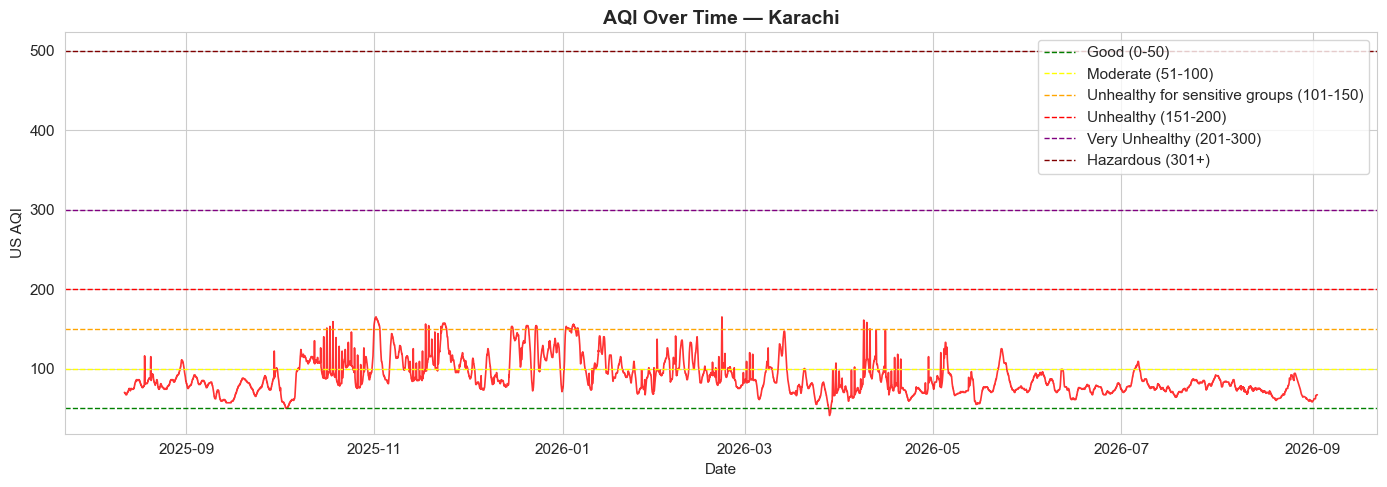

Days above 150 (Unhealthy): 197
Days above 200 (Very Unhealthy): 0


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["timestamp"], df["aqi"], color="red", linewidth=1.2, alpha=0.8)

ax.axhline(50,  color="green", linestyle="--", linewidth=1, label="Good (0-50)")
ax.axhline(100, color="yellow", linestyle="--", linewidth=1, label="Moderate (51-100)")
ax.axhline(150, color="orange", linestyle="--", linewidth=1, label="Unhealthy for sensitive groups (101-150)")
ax.axhline(200, color="red", linestyle="--", linewidth=1, label="Unhealthy (151-200)")
ax.axhline(300, color="purple", linestyle="--", linewidth=1, label="Very Unhealthy (201-300)")
ax.axhline(500, color="maroon", linestyle="--", linewidth=1, label="Hazardous (301+)")

ax.set_title("AQI Over Time — Karachi", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("US AQI")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../notebooks/plots/aqi_over_time.png", dpi=150)
plt.show()
print(f"Days above 150 (Unhealthy): {(df['aqi'] > 150).sum()}")
print(f"Days above 200 (Very Unhealthy): {(df['aqi'] > 200).sum()}")

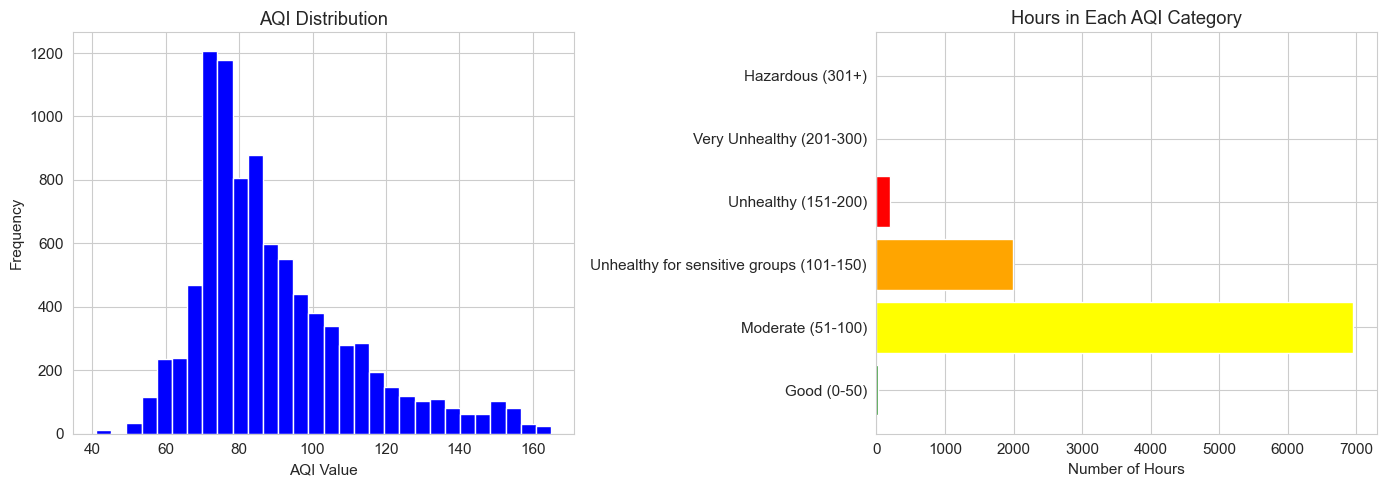

Good (0-50): 28 hours (0.3%)
Moderate (51-100): 6953 hours (75.8%)
Unhealthy for sensitive groups (101-150): 1993 hours (21.7%)
Unhealthy (151-200): 197 hours (2.1%)
Very Unhealthy (201-300): 0 hours (0.0%)
Hazardous (301+): 0 hours (0.0%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["aqi"], bins=30, color="blue", edgecolor="white")
axes[0].set_title("AQI Distribution")
axes[0].set_xlabel("AQI Value")
axes[0].set_ylabel("Frequency")

# AQI category breakdown
categories = {
    "Good (0-50)": (df["aqi"] <= 50).sum(),
    "Moderate (51-100)": ((df["aqi"] > 50) & (df["aqi"] <= 100)).sum(),
    "Unhealthy for sensitive groups (101-150)": ((df["aqi"] > 100) & (df["aqi"] <= 150)).sum(),
    "Unhealthy (151-200)": ((df["aqi"] > 150) & (df["aqi"] <= 200)).sum(),
    "Very Unhealthy (201-300)": ((df["aqi"] > 200) & (df["aqi"] <= 300)).sum(),
    "Hazardous (301+)": (df["aqi"] > 300).sum(),
}
colors = ["green", "yellow", "orange", "red", "purple", "maroon"]
axes[1].barh(list(categories.keys()), list(categories.values()), color=colors)
axes[1].set_title("Hours in Each AQI Category")
axes[1].set_xlabel("Number of Hours")

plt.tight_layout()
plt.savefig("../notebooks/plots/aqi_distribution.png", dpi=150)
plt.show()

for category, count in categories.items():
    percentage = count / len(df) * 100
    print(f"{category}: {count} hours ({percentage:.1f}%)")

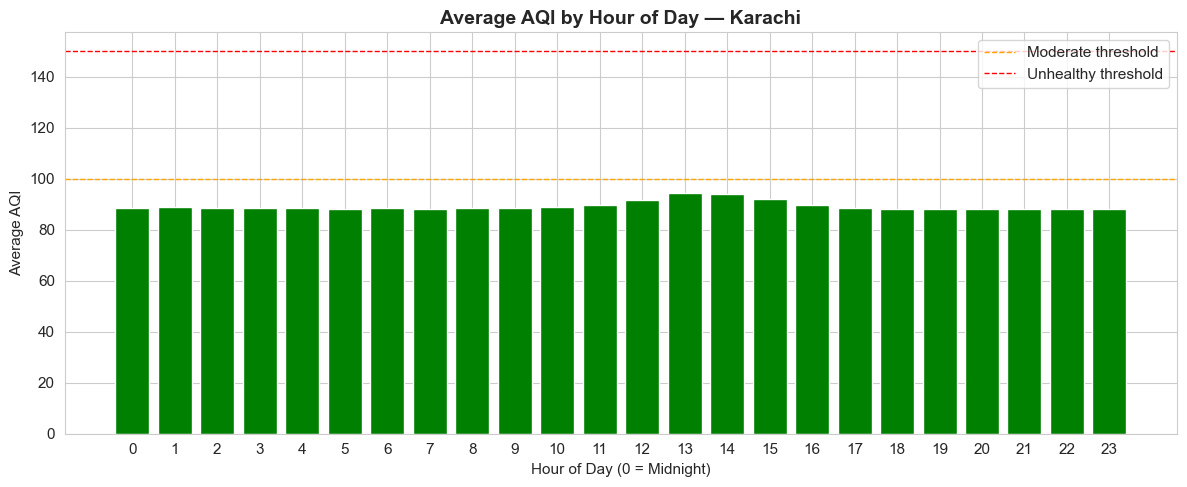

Peak AQI hour: 13:00 (avg 94.3)
Lowest AQI hour: 18:00 (avg 88.1)


In [6]:
hourly_avg = df.groupby("hour")["aqi"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(hourly_avg["hour"], hourly_avg["aqi"], color=["red" if v > 150 else "orange" if v > 100 else "green" for v in hourly_avg["aqi"]])
ax.set_title("Average AQI by Hour of Day — Karachi", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day (0 = Midnight)")
ax.set_ylabel("Average AQI")
ax.set_xticks(range(24))
ax.axhline(100, color="orange", linestyle="--", linewidth=1, label="Moderate threshold")
ax.axhline(150, color="red", linestyle="--", linewidth=1, label="Unhealthy threshold")
ax.legend()
plt.tight_layout()
plt.savefig("../notebooks/plots/aqi_by_hour.png", dpi=150)
plt.show()

peak_hour = hourly_avg.loc[hourly_avg["aqi"].idxmax(), "hour"]
low_hour  = hourly_avg.loc[hourly_avg["aqi"].idxmin(), "hour"]
print(f"Peak AQI hour: {peak_hour}:00 (avg {hourly_avg['aqi'].max():.1f})")
print(f"Lowest AQI hour: {low_hour}:00 (avg {hourly_avg['aqi'].min():.1f})")

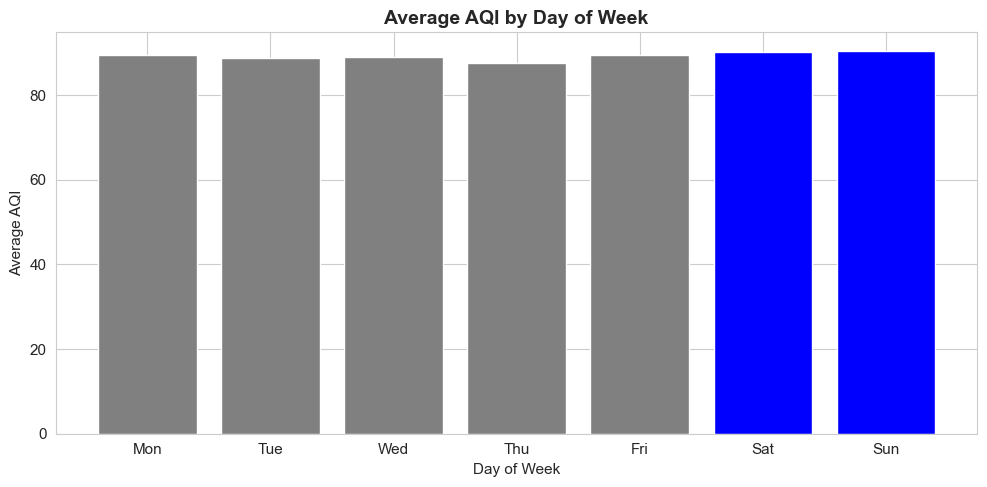

Weekday avg AQI: 88.92
Weekend avg AQI: 90.22


In [7]:
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

daily_avg = df.groupby("day_of_week")["aqi"].mean().reindex(range(7))

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    days,
    daily_avg.values, 
    color=["gray" if i < 5 else "blue" for i in range(7)]
)

ax.set_title("Average AQI by Day of Week", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average AQI")

plt.tight_layout()
plt.savefig("../notebooks/plots/aqi_by_day.png", dpi=150)
plt.show()

print("Weekday avg AQI:", daily_avg[:5].mean().round(2))
print("Weekend avg AQI:", daily_avg[5:].mean().round(2))

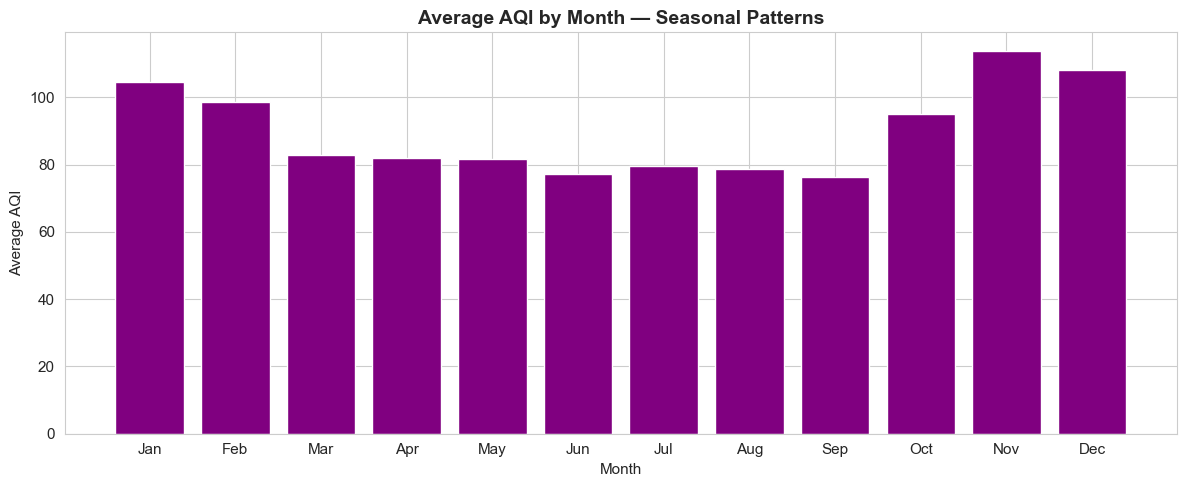

Average AQI by month:
month
1     104.477151
2      98.604167
3      82.727151
4      82.087500
5      81.588710
6      77.255556
7      79.634409
8      78.595633
9      76.434247
10     94.938172
11    113.636111
12    108.176075
Name: aqi, dtype: float64


In [8]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_avg = df.groupby("month")["aqi"].mean().reindex(range(1, 13))

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(months[:len(monthly_avg)], monthly_avg.values, color="purple")

ax.set_title("Average AQI by Month — Seasonal Patterns", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Average AQI")

plt.tight_layout()
plt.savefig("../notebooks/plots/aqi_by_month.png", dpi=150)
plt.show()

print("Average AQI by month:")
print(monthly_avg)

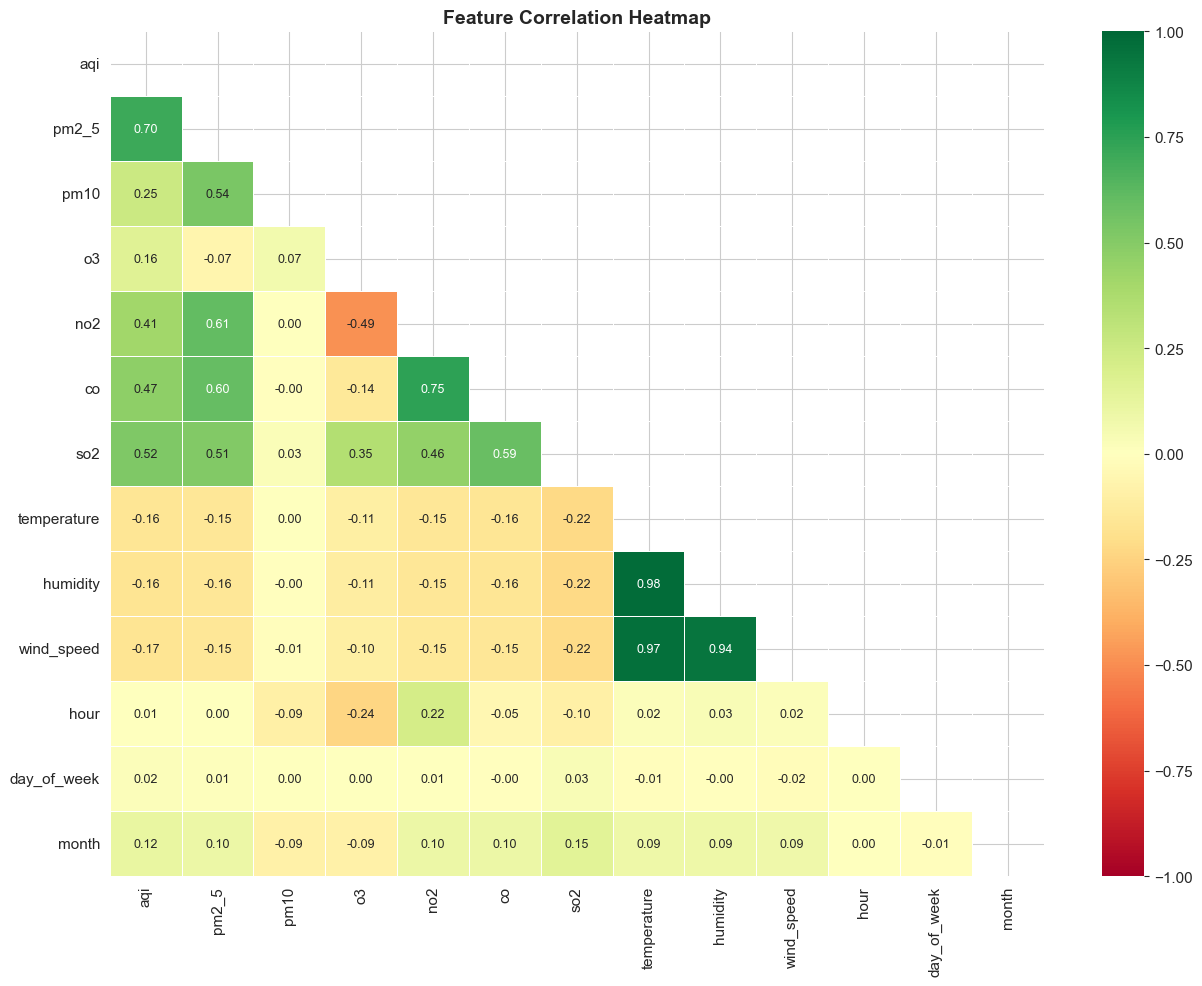

Top correlations with AQI:
pm2_5          0.704925
so2            0.516362
co             0.473545
no2            0.406384
pm10           0.250313
wind_speed     0.165462
humidity       0.164102
temperature    0.163236
Name: aqi, dtype: float64


In [9]:
feature_cols = ["aqi", "pm2_5", "pm10", "o3", "no2", "co", "so2", "temperature", "humidity", "wind_speed", "hour", "day_of_week", "month"]

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={"size": 9})

ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../notebooks/plots/correlation_heatmap.png", dpi=150)
plt.show()

print("Top correlations with AQI:")
aqi_corr = corr["aqi"].drop("aqi").abs().sort_values(ascending=False)
print(aqi_corr.head(8))

            timestamp  aqi  aqi_change_rate
0 2025-08-12 00:00:00   70              NaN
1 2025-08-12 01:00:00   70              0.0
2 2025-08-12 02:00:00   70              0.0
3 2025-08-12 03:00:00   69             -1.0
4 2025-08-12 04:00:00   69              0.0
5 2025-08-12 05:00:00   69              0.0
6 2025-08-12 06:00:00   69              0.0
7 2025-08-12 07:00:00   69              0.0
8 2025-08-12 08:00:00   68             -1.0
9 2025-08-12 09:00:00   68              0.0


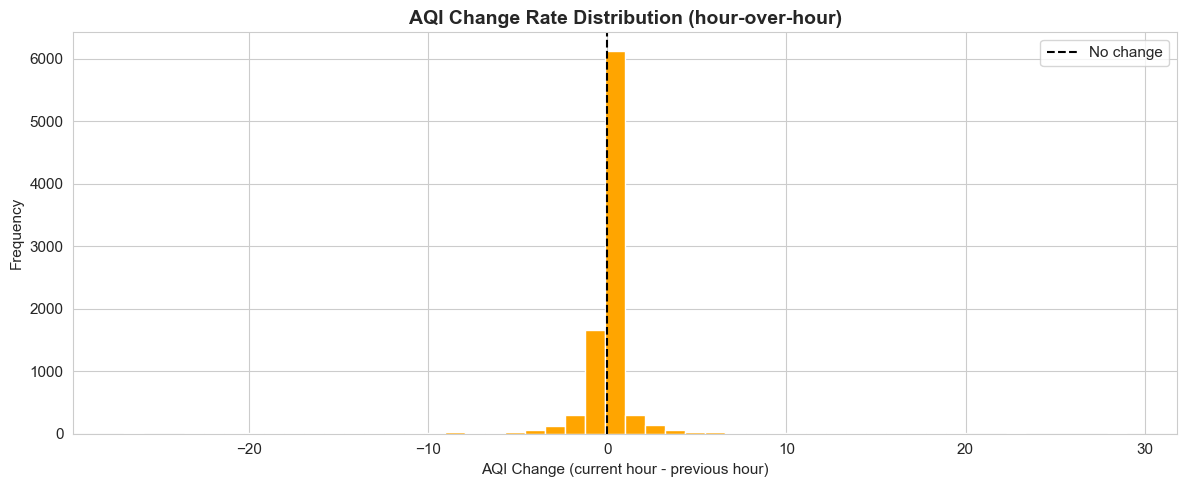

Mean change per hour: -0.00
Max increase in one hour: 29.00
Max decrease in one hour: -27.00


In [10]:
df = df.sort_values("timestamp").reset_index(drop=True)
df["aqi_change_rate"] = df["aqi"].diff()
print(df[["timestamp", "aqi", "aqi_change_rate"]].head(10))

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df["aqi_change_rate"].dropna(), bins=50, color="orange", edgecolor="white")

ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="No change")

ax.set_title("AQI Change Rate Distribution (hour-over-hour)", fontsize=14, fontweight="bold")

ax.set_xlabel("AQI Change (current hour - previous hour)")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.savefig("../notebooks/plots/aqi_change_rate.png", dpi=150)
plt.show()

print(f"Mean change per hour: {df['aqi_change_rate'].mean():.2f}")
print(f"Max increase in one hour: {df['aqi_change_rate'].max():.2f}")
print(f"Max decrease in one hour: {df['aqi_change_rate'].min():.2f}")